In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

print("PyTorch version:", torch.__version__)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

PyTorch version: 2.11.0+cpu
Device: cpu


In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Random seed:", SEED)

Random seed: 42


In [4]:
DATASET_PATH = "/content/drive/MyDrive/IITG dataset/cleaned_dataset"

V1_PATH = os.path.join(
    DATASET_PATH,
    "processed_dataset_v1"
)

print("Dataset path:")
print(V1_PATH)

Dataset path:
/content/drive/MyDrive/IITG dataset/cleaned_dataset/processed_dataset_v1


In [5]:
data = np.load(
    os.path.join(V1_PATH, "sequences_v1.npz"),
    allow_pickle=True
)

X_sequences = data["X"]
y_soh = data["SoH"]
y_rul = data["RUL"]

sequence_battery_ids = data["battery_id"]
sequence_splits = data["split"]

print("Dataset V1 loaded successfully.")

print("X shape:", X_sequences.shape)
print("SoH shape:", y_soh.shape)
print("RUL shape:", y_rul.shape)
print("Split shape:", sequence_splits.shape)

Dataset V1 loaded successfully.
X shape: (2287, 10, 2)
SoH shape: (2287,)
RUL shape: (2287,)
Split shape: (2287,)


In [6]:
train_mask = sequence_splits == "train"
val_mask = sequence_splits == "validation"
test_mask = sequence_splits == "test"

X_train = X_sequences[train_mask]
X_val = X_sequences[val_mask]
X_test = X_sequences[test_mask]

y_soh_train = y_soh[train_mask]
y_soh_val = y_soh[val_mask]
y_soh_test = y_soh[test_mask]

y_rul_train = y_rul[train_mask]
y_rul_val = y_rul[val_mask]
y_rul_test = y_rul[test_mask]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (1516, 10, 2)
Validation: (379, 10, 2)
Test: (392, 10, 2)


In [7]:
# Day 16 - Cell 7
# Convert data to PyTorch tensors

X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    np.column_stack([
        y_soh_train,
        y_rul_train
    ]),
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    np.column_stack([
        y_soh_val,
        y_rul_val
    ]),
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    np.column_stack([
        y_soh_test,
        y_rul_test
    ]),
    dtype=torch.float32
)

print("Tensor conversion completed.")
print("X_train:", X_train_tensor.shape)
print("y_train:", y_train_tensor.shape)

Tensor conversion completed.
X_train: torch.Size([1516, 10, 2])
y_train: torch.Size([1516, 2])


In [8]:
# Day 16 - Cell 8
# Create DataLoaders

BATCH_SIZE = 32

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("DataLoaders created successfully.")
print("Batch size:", BATCH_SIZE)
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

DataLoaders created successfully.
Batch size: 32
Training batches: 48
Validation batches: 12
Test batches: 13


In [10]:
# Day 16 - Cell 9
# GRU Model

class GRUModel(nn.Module):

    def __init__(
        self,
        input_size=2,
        hidden_size=64,
        num_layers=2,
        output_size=2,
        dropout=0.2
    ):
        super(GRUModel, self).__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Linear(
            hidden_size,
            output_size
        )

    def forward(self, x):

        out, hidden = self.gru(x)

        out = out[:, -1, :]

        out = self.fc(out)

        return out


model = GRUModel().to(device)

print(model)

GRUModel(
  (gru): GRU(2, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)


In [11]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Loss function:", criterion)
print("Optimizer: Adam")
print("Learning rate: 0.001")
print("Total parameters:", total_parameters)
print("Trainable parameters:", trainable_parameters)

Loss function: MSELoss()
Optimizer: Adam
Learning rate: 0.001
Total parameters: 38146
Trainable parameters: 38146


In [12]:
NUM_EPOCHS = 100

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_epoch = 0

CHECKPOINT_PATH = os.path.join(
    V1_PATH,
    "gru_best_model.pth"
)

start_time = time.time()

for epoch in range(NUM_EPOCHS):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = model(X_batch)

        loss = criterion(predictions, y_batch)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item() * X_batch.size(0)

    epoch_train_loss = (
        running_train_loss /
        len(train_loader.dataset)
    )

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(X_batch)

            loss = criterion(predictions, y_batch)

            running_val_loss += (
                loss.item() * X_batch.size(0)
            )

    epoch_val_loss = (
        running_val_loss /
        len(val_loader.dataset)
    )

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    # -------------------------
    # Save best model
    # -------------------------
    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss
        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            CHECKPOINT_PATH
        )

    # -------------------------
    # Print progress
    # -------------------------
    if (epoch + 1) % 10 == 0 or epoch == 0:

        print(
            f"Epoch [{epoch+1:3d}/{NUM_EPOCHS}] "
            f"Train Loss: {epoch_train_loss:.6f} "
            f"Val Loss: {epoch_val_loss:.6f}"
        )

training_time = time.time() - start_time

print("\nTraining completed.")
print("Best Epoch:", best_epoch)
print("Best Validation Loss:", best_val_loss)
print(f"Training Time: {training_time:.2f} seconds")
print("Checkpoint:", CHECKPOINT_PATH)

Epoch [  1/100] Train Loss: 3153.773557 Val Loss: 2189.931999
Epoch [ 10/100] Train Loss: 1506.133734 Val Loss: 963.163360
Epoch [ 20/100] Train Loss: 829.523368 Val Loss: 452.358115
Epoch [ 30/100] Train Loss: 628.884159 Val Loss: 344.167153
Epoch [ 40/100] Train Loss: 590.973783 Val Loss: 350.033378
Epoch [ 50/100] Train Loss: 587.254333 Val Loss: 357.162389
Epoch [ 60/100] Train Loss: 587.122709 Val Loss: 361.185913
Epoch [ 70/100] Train Loss: 587.175072 Val Loss: 362.273311
Epoch [ 80/100] Train Loss: 587.166381 Val Loss: 361.571769
Epoch [ 90/100] Train Loss: 587.132001 Val Loss: 362.529003
Epoch [100/100] Train Loss: 587.145910 Val Loss: 361.055863

Training completed.
Best Epoch: 35
Best Validation Loss: 340.86395334128025
Training Time: 82.66 seconds
Checkpoint: /content/drive/MyDrive/IITG dataset/cleaned_dataset/processed_dataset_v1/gru_best_model.pth


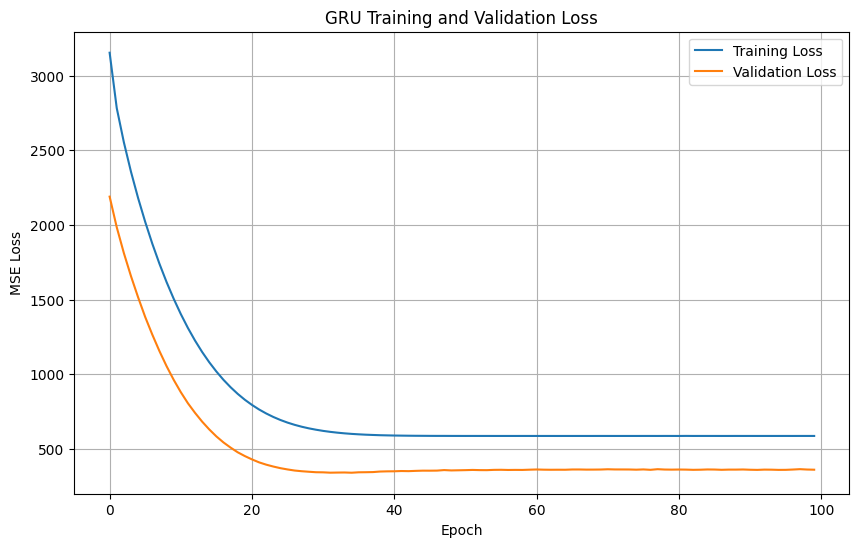

In [13]:
plt.figure(figsize=(10, 6))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("GRU Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [14]:
# Load the best GRU model

model.load_state_dict(
    torch.load(CHECKPOINT_PATH, map_location=device)
)

model.eval()

print("Best GRU checkpoint loaded successfully.")
print("Best Epoch:", best_epoch)
print("Best Validation Loss:", best_val_loss)

Best GRU checkpoint loaded successfully.
Best Epoch: 35
Best Validation Loss: 340.86395334128025


In [15]:
# Generate predictions on the test set

all_predictions = []
all_targets = []

model.eval()

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        predictions = model(X_batch)

        all_predictions.append(
            predictions.cpu().numpy()
        )

        all_targets.append(
            y_batch.numpy()
        )

y_pred = np.concatenate(all_predictions, axis=0)
y_true = np.concatenate(all_targets, axis=0)

print("Test evaluation completed.")
print("Actual shape:", y_true.shape)
print("Predicted shape:", y_pred.shape)

Test evaluation completed.
Actual shape: (392, 2)
Predicted shape: (392, 2)


In [16]:
# Separate SoH and RUL predictions

soh_true = y_true[:, 0]
soh_pred = y_pred[:, 0]

rul_true = y_true[:, 1]
rul_pred = y_pred[:, 1]

print("SoH actual shape:", soh_true.shape)
print("SoH predicted shape:", soh_pred.shape)

print("RUL actual shape:", rul_true.shape)
print("RUL predicted shape:", rul_pred.shape)

SoH actual shape: (392,)
SoH predicted shape: (392,)
RUL actual shape: (392,)
RUL predicted shape: (392,)


In [17]:
# Calculate SoH and RUL test metrics

def calculate_metrics(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mape = (
        mean_absolute_percentage_error(y_true, y_pred)
        * 100
    )

    r2 = r2_score(y_true, y_pred)

    return mae, rmse, mape, r2


# SoH metrics
soh_mae, soh_rmse, soh_mape, soh_r2 = calculate_metrics(
    soh_true,
    soh_pred
)

# RUL metrics
rul_mae, rul_rmse, rul_mape, rul_r2 = calculate_metrics(
    rul_true,
    rul_pred
)


# Create results table
gru_results = pd.DataFrame({
    "Target": ["SoH", "RUL"],
    "MAE": [soh_mae, rul_mae],
    "RMSE": [soh_rmse, rul_rmse],
    "MAPE (%)": [soh_mape, rul_mape],
    "R2": [soh_r2, rul_r2]
})


print("GRU Test Results")
print("=" * 60)
print(gru_results.to_string(index=False))

GRU Test Results
Target      MAE      RMSE     MAPE (%)          R2
   SoH 9.851915 15.599961 4.776253e+17   -0.020081
   RUL 9.803580  9.829659 4.365551e+18 -187.724731
